# Detector rotation angle diagnostic — mfx101609126
Use `XSpectDetectorProcessor` to inspect the summed image, edge map, and detected rotation angle before committing values to the pipeline YAML.

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')

import h5py
import numpy as np
import matplotlib.pyplot as plt
from XSpect.XSpect_Processor.XSpectDetectorProcessor import XSpectDetectorProcessor

## Load summed images for both detectors

In [2]:
H5_PATH = '/sdf/data/lcls/ds/mfx/mfx101609126/hdf5/smalldata/mfx101609126_Run0079.h5'

with h5py.File(H5_PATH, 'r') as f:
    xray = f['lightStatus/xray'][:].astype(bool)
    img_spec = f['epix100_0/ROI_area'][:][xray].sum(axis=0).clip(0).astype(float)
    img_seer = f['epix100_1/ROI_area'][:][xray].sum(axis=0).clip(0).astype(float)

print(f'epix100_0 (spec) sum image: {img_spec.shape}  max={img_spec.max():.0f}')
print(f'epix100_1 (SEER) sum image: {img_seer.shape}  max={img_seer.max():.0f}')

epix100_0 (spec) sum image: (60, 300)  max=349746
epix100_1 (SEER) sum image: (100, 620)  max=2838


## Raw sum images

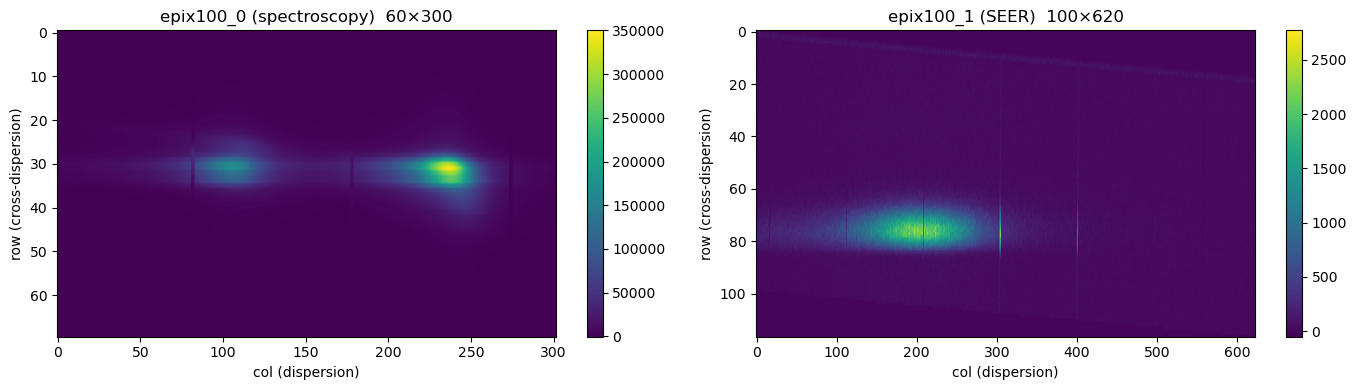

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
from scipy.ndimage import rotate
for ax, img, title in [
    (axes[0], rotate(img_spec,-2), 'epix100_0 (spectroscopy)  60×300'),
    (axes[1], rotate(img_seer,-1.6), 'epix100_1 (SEER)  100×620'),
]:
    im = ax.imshow(img, aspect='auto', origin='upper', cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('col (dispersion)')
    ax.set_ylabel('row (cross-dispersion)')

plt.tight_layout()
plt.show()

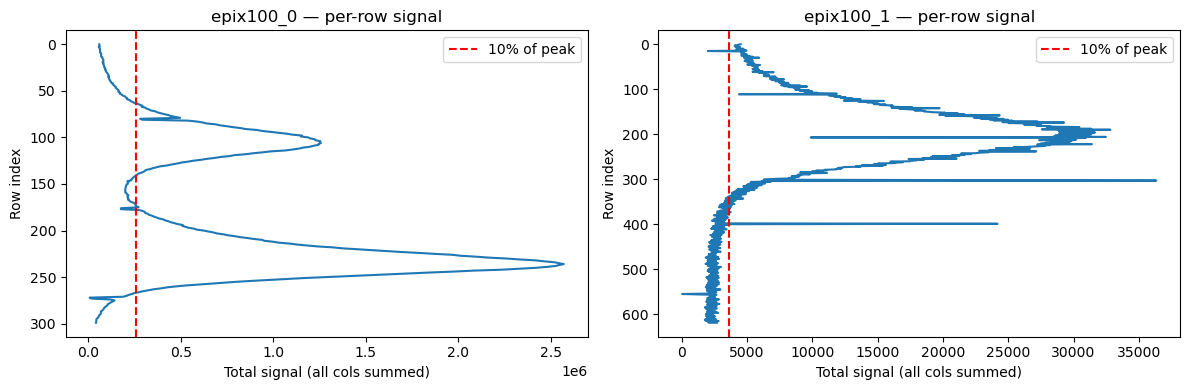

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, img, title in [
    (axes[0], img_spec, 'epix100_0'),
    (axes[1], img_seer, 'epix100_1'),
]:
    row_totals = img.sum(axis=0)
    ax.plot(row_totals, np.arange(len(row_totals)))
    ax.invert_yaxis()
    ax.set_xlabel('Total signal (all cols summed)')
    ax.set_ylabel('Row index')
    ax.set_title(f'{title} — per-row signal')
    ax.axvline(row_totals.max() * 0.1, color='red', ls='--', label='10% of peak')
    ax.legend()

plt.tight_layout()
plt.show()

## Per-row signal profile
Shows where signal rows are — helps choose `rois:` in the YAML.

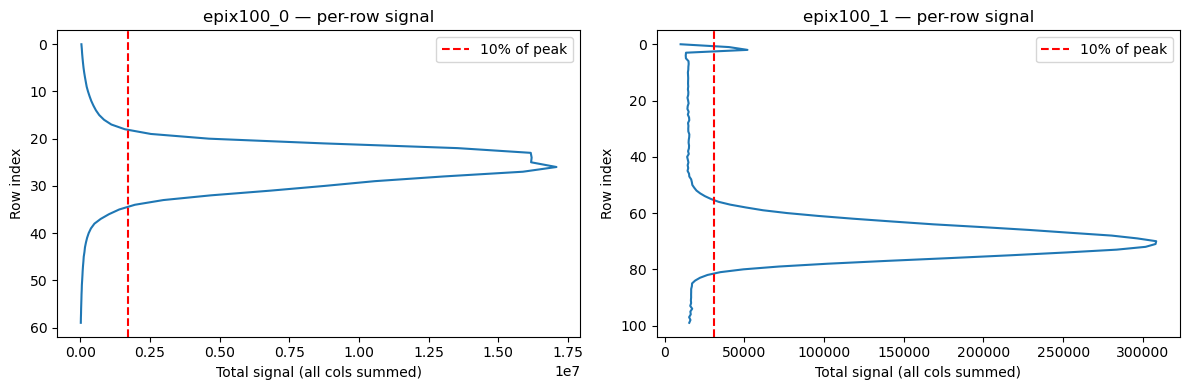

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, img, title in [
    (axes[0], img_spec, 'epix100_0'),
    (axes[1], img_seer, 'epix100_1'),
]:
    row_totals = img.sum(axis=1)
    ax.plot(row_totals, np.arange(len(row_totals)))
    ax.invert_yaxis()
    ax.set_xlabel('Total signal (all cols summed)')
    ax.set_ylabel('Row index')
    ax.set_title(f'{title} — per-row signal')
    ax.axvline(row_totals.max() * 0.1, color='red', ls='--', label='10% of peak')
    ax.legend()

plt.tight_layout()
plt.show()

## XSpectDetectorProcessor — edge detection and angle finding

Tune `low_threshold` and `high_threshold` until the edge map cleanly outlines
the signal streak without too much noise.  The `plot_images()` call shows
original / edges / aligned side by side.

epix100_0 detected angle: -1.829 deg
  per-cluster angles: ['-1.83']


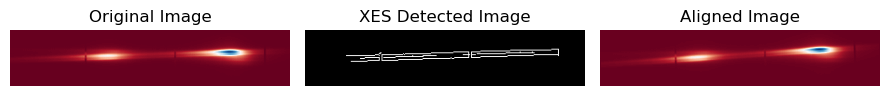

In [6]:
# --- epix100_0 (spectroscopy) ---
LOW, HIGH = 30, 100   # tune these if edges look noisy or incomplete

proc_spec = XSpectDetectorProcessor(img_spec)
proc_spec.detect_edges(low_threshold=LOW, high_threshold=HIGH)
angle_spec = proc_spec.find_optimal_rotation_angle()
proc_spec.align_image()

print(f'epix100_0 detected angle: {angle_spec:.3f} deg')
print(f'  per-cluster angles: {[f"{a:.2f}" for a in proc_spec.angles]}')
proc_spec.plot_images()

epix100_1 detected angle: 3.071 deg
  per-cluster angles: ['90.00', '-1.70']


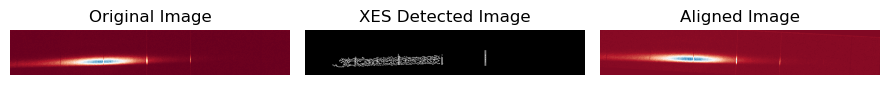

In [7]:
# --- epix100_1 (SEER) ---
LOW_S, HIGH_S = 30, 100   # tune independently if needed

proc_seer = XSpectDetectorProcessor(img_seer)
proc_seer.detect_edges(low_threshold=LOW_S, high_threshold=HIGH_S)
angle_seer = proc_seer.find_optimal_rotation_angle()
proc_seer.align_image()

print(f'epix100_1 detected angle: {angle_seer:.3f} deg')
print(f'  per-cluster angles: {[f"{a:.2f}" for a in proc_seer.angles]}')
proc_seer.plot_images()

## Verify ROI rows on aligned images

Once the images look straight, check which rows the signal actually occupies
and update `rois:` in `mfx101609126_pershot_xes.yaml` accordingly.

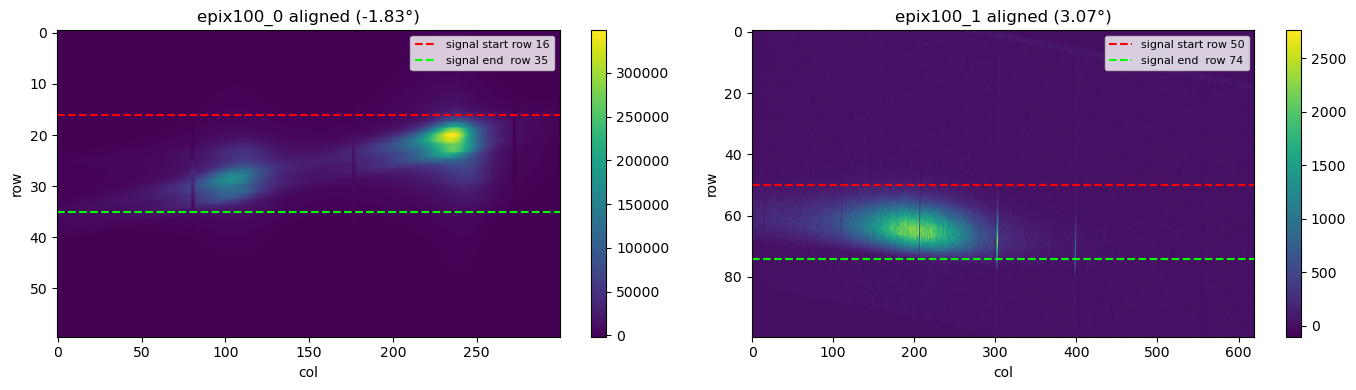

Suggested rois for YAML:
  epix_spec: rois: [[16, 35]]
  epix_seer: rois: [[50, 74]]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, proc, title in [
    (axes[0], proc_spec, f'epix100_0 aligned ({angle_spec:.2f}°)'),
    (axes[1], proc_seer, f'epix100_1 aligned ({angle_seer:.2f}°)'),
]:
    aligned = proc.aligned_image
    row_totals = aligned.sum(axis=1)
    im = ax.imshow(aligned, aspect='auto', origin='upper', cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('col')
    ax.set_ylabel('row')

    # Overlay 10%-of-peak row markers
    threshold = row_totals.max() * 0.1
    signal_rows = np.where(row_totals > threshold)[0]
    if len(signal_rows):
        ax.axhline(signal_rows[0],  color='red',  ls='--', lw=1.5, label=f'signal start row {signal_rows[0]}')
        ax.axhline(signal_rows[-1], color='lime', ls='--', lw=1.5, label=f'signal end  row {signal_rows[-1]}')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Suggested rois for YAML:')
for proc, name in [(proc_spec, 'epix_spec'), (proc_seer, 'epix_seer')]:
    rt = proc.aligned_image.sum(axis=1)
    thresh = rt.max() * 0.1
    rows = np.where(rt > thresh)[0]
    if len(rows):
        print(f'  {name}: rois: [[{rows[0]}, {rows[-1]}]]')

## Summary — copy these values into the YAML

Once you are happy with the angles and ROIs above, update
`examples/mfx101609126_pershot_xes.yaml`:

```yaml
  - step: find_rotation_angle
    on: epix_spec
    low_threshold: <LOW>
    high_threshold: <HIGH>

  - step: find_rotation_angle
    on: epix_seer
    low_threshold: <LOW_S>
    high_threshold: <HIGH_S>

  - step: reduce_detector_spatial
    on: epix_spec
    rois: [[<start>, <end>]]
    ...

  - step: reduce_detector_spatial
    on: epix_seer
    rois: [[<start>, <end>]]
    ...
```